In [1]:
import os
import math
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from graphcast.model_utils import stacked_to_dataset
from graphcast.losses import normalized_latitude_weights
from graphufs.stacked_utils import get_channel_index
from graphufs.datasets import Dataset
from prototypes.ocn_only.emulator import OcnEvaluator, OcnTrainer
from scipy import stats

In [2]:
plt.style.use("graphufs.plotstyle")

In [3]:
def persistence_fcast(model_type:str, prototype:str, eval_dates:list[str], num_missing_samples:int, fcast_nhours="240h"):

    #### SETUP ####
    emulator = OcnEvaluator(prototype)
    preserved_dims = ("batch", "lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the validation data
    valid_dir = f"{emulator.local_store_path}/validation"
    validation_inputs = xr.open_zarr(f"{valid_dir}/inputs.zarr")["inputs"] # (sample, lat, lon, channels)

    # Calculate the date ranges and find the integer indices for slicing
    validation_datetime = pd.date_range(
        start=pd.to_datetime(emulator.validation_dates[0]),
        end=(pd.to_datetime(emulator.validation_dates[1]) - 
             pd.Timedelta(emulator.delta_t_model)) - num_missing_samples*pd.Timedelta(emulator.delta_t_data),
        freq=pd.Timedelta(emulator.delta_t_data),
        inclusive="both",
    )
    
    # check the length of the validation dataset = validation datetime
    assert len(validation_datetime)==validation_inputs.sizes["sample"], \
    f"Error: Length of the time stamp vector and validation inputs did not match: {len(validation_datetime)}, {validation_inputs.sizes['sample']}"

    idx_start = validation_datetime.get_loc(pd.to_datetime(eval_dates[0]))
    idx_end = validation_datetime.get_loc(pd.to_datetime(eval_dates[1]))

    # Select the evaluation data and rename 'sample' to 'batch' for consistency
    eval_inputs = validation_inputs.sel(sample=slice(idx_start, idx_end, emulator.sample_stride)
    ).rename({"sample": "batch"}) # (batch=292, lat, lon, channels)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )
    
    # assert the lengths of the eval datetime vector and the eval dataset
    assert len(eval_datetime)==eval_inputs.sizes["batch"], \
    f"Error: Length of the eval datetime vector and eval inputs did not match:" \
    f"{len(eval_datetime)}, {eval_inputs.sizes['batch']}"

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
    meta_xinputs = get_channel_index(xinputs)

    for variable in xinputs.data_vars:
        dims_to_ensure = preserved_dims #tuple(d for d in preserved_dims if d != "batch")
        dims_not_present = [d for d in dims_to_ensure if d not in xinputs[variable].dims]
        for dimen in dims_not_present:
            xinputs[variable] = xinputs[variable].expand_dims(dim={dimen:eval_inputs.coords[dimen]})
        # make sure that the batch dimension has the same size in both datasets. Actually all
        # preserved dims must have the same size in both.
        if xinputs.sizes["batch"] != eval_inputs.sizes["batch"]:
            xinputs = xinputs.reindex({"batch":eval_inputs.coords["batch"]}, method="pad")
        xinputs[variable] = xinputs[variable].transpose("batch", ..., "lat", "lon")

    #### UNSTACK VALIDATION DATA ####
    # Only consider the input channels, not forcing. Note that xinputs would not have
    # forcing channels appended at the end. Just choose the inputs because the mapping
    # is only for inputs and this is what we need essentially.
    eval_inputs = eval_inputs.isel(channels=slice(None, len(meta_xinputs)))

    # Unstack the data by passing the underlying .variable object
    eval_inputs_unstacked = stacked_to_dataset(eval_inputs.variable, 
                                               xinputs, preserved_dims=preserved_dims)
    
    # now return the persistence in the same form as targets
    ds_persistence_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    for variable in xtargets.data_vars:
        var = eval_inputs_unstacked[variable].isel(time=-1, drop=True)
        var = var.rename(batch="time").assign_coords(time=eval_datetime)
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_persistence_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_persistence_fcast

In [4]:
def climatology(model_type:str, prototype:str):

    #### SETUP ####
    ocn_only_home = f"/global/homes/n/nagarwal/graph-ufs/prototypes/{model_type}"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
    preserved_dims = ("lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the training data
    train_dir = f"{emulator.local_store_path}/training"
    training_targets = xr.open_zarr(f"{train_dir}/targets.zarr")["targets"] # (sample, lat, lon, channels)

    # climatology
    climatology = training_targets.mean(dim="sample") # (lat, lon, channels)

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)

    #### UNSTACK CLIMATOLOGY ####
    clima_unstacked = stacked_to_dataset(climatology.variable, 
                                         xtargets.isel(batch=0, time=0, drop=True), 
                                         preserved_dims=preserved_dims)
    return clima_unstacked

In [5]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [6]:
def calculate_metrics_for_model(model_pred, ref_truth, clima):
    """
    Calculates sq_error, abs_error, acc for a given model against a truth reference.
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    sq_error_vars = {}
    abs_error_vars = {}
    acc_vars = {}

    # Pre-calculate reference anomaly
    reference_anomaly_all = ref_truth - clima
    
    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute errors and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask
        sq_error_vars[var] = error**2
        abs_error_vars[var] = abs(error)

        # Calculate anomalies using the masked data
        forecast_anomaly = (model_pred[var] - clima[var]) * current_mask
        reference_anomaly = reference_anomaly_all[var] * current_mask
        
        # Calculate Anomaly Correlation Coefficient
        acc_vars[var] = xr.corr(
            forecast_anomaly, 
            reference_anomaly, 
            dim=("lat", "lon")
        ).compute()
        
    return sq_error_vars, abs_error_vars, acc_vars

In [20]:
def calculate_rmse(sqerr_da, apply_weighting=False, depth_level=None, 
                   depth_unit="dimensionless"):
    """
    Calculates the Root Mean Squared Error from a squared error DataArray.
    
    This function correctly preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in sqerr_da.dims and depth_level is not None:
        if depth_unit.lower() == "dimensionless": 
            sqerr_da = sqerr_da.isel(z_l=depth_level)
        else:
            sqerr_da = sqerr_da.sel(z_l=depth_level, method="nearest")
            
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(sqerr_da)
        sqerr_da = sqerr_da * weights.astype(sqerr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    # The 'time' dimension (or 'init_time') holds the samples for the CI.
    dims_to_avg = [dim for dim in sqerr_da.dims if dim not in ["lead_time", "time"]]
    
    # Calculate the mean over spatial dimensions and take the square root
    rmse_da = np.sqrt(sqerr_da.mean(dim=dims_to_avg))
    
    return rmse_da

In [23]:
def calculate_mae(abserr_da, apply_weighting=False, depth_level=None,
                  depth_unit="dimensionless"):
    """
    Calculates the Mean Absolute Error from an absolute error DataArray.
    
    This function preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in abserr_da.dims and depth_level is not None:
        if depth_unit.lower() == "dimensionless":
            abserr_da = abserr_da.isel(z_l=depth_level)
        else:
            abserr_da = abserr_da.sel(z_l=depth_level, method="nearest")
    
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(abserr_da)
        abserr_da = abserr_da * weights.astype(abserr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    dims_to_avg = [dim for dim in abserr_da.dims if dim not in ["lead_time", "time"]]
    
    # Calculate the mean over spatial dimensions
    mae_da = abserr_da.mean(dim=dims_to_avg)
    
    return mae_da

In [9]:
# ---- Meta and Model Configs ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-MLoss",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
    {
        "name": "Persistence-24h",
        "type": "persistence",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "",
        "pred_prefix": "persistence",
        "timestep": "24h",
        "duration": "240h",
        "description": "persistence",
        "num_missing_samples": 0, # or, 3
    }
]

# Squared Error, Abs Error, ACC

In [10]:
# ---- Main computation block ----
# Initialize dictionaries to store all results
all_sq_error = {}
all_abs_error = {}
all_acc = {}

print("Loading climatology data...")
clima = climatology("ocn_only", "R5").load() 
print("Climatology loaded!!")

# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")
        
    all_sq_error[model_name] = {}
    all_abs_error[model_name] = {}
    all_acc[model_name] = {}
        
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate all metrics for this model against this truth
        sq_err, abs_err, acc = calculate_metrics_for_model(model_pred, ref_truth, clima)
            
        # Store results
        all_sq_error[model_name][truth_name] = sq_err
        all_abs_error[model_name][truth_name] = abs_err
        all_acc[model_name][truth_name] = acc 
        

print("\n --- Metric calculation complete!! ---")

Loading climatology data...
Climatology loaded!!

Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...

Processing Model: Emulator-24h-MLoss
Comparing against truth: Replay ...

Processing Model: Persistence-24h
Comparing against truth: Replay ...

 --- Metric calculation complete!! ---


## Plotting

In [11]:
def ttest(data1, data2, inflate=False):
    n = data1.shape[0] # number of samples
    d1 = ((data1 - data2)**2).sum(axis=0) # sum of squared difference
    d2 = (data1 - data2).sum(axis=0) # sum of the difference
    sd = np.sqrt((d1 - (d2**2 / n)) / (n - 1)) # standard deviation of the difference between the means

    # standard error of the difference between means
    # inflation to represent autocorrelation (see Geer 2016 appendix, Wilks 2006 for details)
    inflation = 1.0
    if inflate:
        x = data1 - data2
        r1 = np.array([np.corrcoef(x[:-1, i], x[1:, i], rowvar=False)[0, 1] for i in range(x.shape[1])])
        r2 = np.array([np.corrcoef(x[:-2, i], x[2:, i], rowvar=False)[0, 1] for i in range(x.shape[1])])
        phi1 = r1 * (1. - r2) / (1. - r1**2)
        phi2 = (r2 - r1**2) / (1. - r1**2)
        rho1 = phi1 / (1. - phi2)
        rho2 = phi2 + phi1**2 / (1. - phi2)
        inflation = np.sqrt((1. - rho1*phi1 - rho2*phi2) / (1. - phi1 - phi2)**2)
        inflation = np.where(inflation < 1.0, 1.0, inflation)

    print("Inflation factor:", inflation)
    # effective sample size
    n_eff = n / inflation**2  # effective sample size
    
    # standard error of the difference 
    sed = inflation * sd / np.sqrt(n)
    
    # calculate the t statistic
    t_stat = (data1 - data2).mean(axis=0) / sed

    # return the p-values and sed
    return 1. - (1. - stats.t.cdf(abs(t_stat), n_eff - 1)) * 2.0, sed

In [12]:
def plot_error_vs_leadtime_seaborn_ttest(
    ax,
    da: xr.DataArray,
    da_ref: xr.DataArray = None,
    var_name: str = None,
    unit: str = None,
    timestep: str = "6h",
    forecast_days: int = 10,
    label: str = "",
    ytitle: str = "RMSE",
    vmin: float = None,
    vmax: float = None,
    show_title: bool = True,
    show_xlabel: bool = True,
    apply_latitude_weighting: bool = True,
    inflate_ci: bool = True,
    ci: float = 0.95,
):
    # --- Subsample to daily lead times ---
    hours_to_plot = [d * 24 for d in range(1, forecast_days + 1)]
    lead_time_hours = da['lead_time'].values / np.timedelta64(1, 'h')
    mask = np.isin(lead_time_hours, hours_to_plot)
    da_sub = da.isel(lead_time=mask)                          # (init_time, lead_time)
    lead_days = da_sub['lead_time'].values / np.timedelta64(1, 'D')

    # --- Compute CI via ttest ---
    data = da_sub.values                                       # (n_inits, n_leads)
    ref = da_ref.isel(lead_time=mask).values if da_ref is not None else np.zeros_like(data)
    _, sed = ttest(data, ref, inflate=inflate_ci)
    means = data.mean(axis=0)
    t_crit = stats.t.ppf(1 - (1 - ci) / 2, df=data.shape[0] - 1)
    ci_lower, ci_upper = means - t_crit * sed, means + t_crit * sed

    # --- Plot ---
    line = ax.plot(lead_days, means, marker='o', linewidth=2, markersize=8, label=label)
    ax.fill_between(lead_days, ci_lower, ci_upper, alpha=0.2, color=line[0].get_color())

    # --- Formatting ---
    if vmin is not None and vmax is not None:
        ax.set_ylim(vmin, vmax)
    ylabel = f"{ytitle}\n[{unit}]" if unit else ytitle
    if apply_latitude_weighting:
        ylabel = f"LW-{ylabel}"
    ax.set_xlabel("Forecast Lead Time [days]" if show_xlabel else "", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xticks(np.arange(1, forecast_days + 1))
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)
    if show_title:
        ax.set_title(var_name, fontsize=14)

    return ax

In [13]:
def plot_acc_vs_leadtime_seaborn_ttest(
    ax,
    da: xr.DataArray,
    var_name: str = None,
    unit: str = None,
    timestep: str = "6h",
    forecast_days: int = 10,
    label: str = "",
    ytitle: str = "ACC",
    vmin: float = 0,
    vmax: float = 1,
    show_title: bool = True,
    show_xlabel: bool = True,
    inflate_ci: bool = True,
    ci: float = 0.95,
):
    # --- 1. Subsample to daily lead times ---
    hours_to_plot = [d * 24 for d in range(1, forecast_days + 1)]
    lead_time_hours = da['lead_time'].values / np.timedelta64(1, 'h')
    mask = np.isin(lead_time_hours, hours_to_plot)
    da_sub = da.isel(lead_time=mask)                          # (init_time, lead_time)
    lead_days = da_sub['lead_time'].values / np.timedelta64(1, 'D')

    # --- 2. compute CI via ttest ---
    data = da_sub.values                                       # (n_inits, n_leads)
    data_ref = np.ones_like(data)                             # one-sample: compare against zero

    _, sed = ttest(data, data_ref, inflate=inflate_ci)
    t_crit = stats.t.ppf(1 - (1 - ci) / 2, df=data.shape[0] - 1)

    data_mean = data.mean(axis=0)
    ci_lower = np.clip(data_mean - t_crit * sed, -1, 1)
    ci_upper = np.clip(data_mean + t_crit * sed, -1, 1)
    #ci_lower = data_mean - t_crit * sed
    #ci_upper = data_mean + t_crit * sed

    # --- 3. Plot ---
    line = ax.plot(lead_days, data_mean, marker='o', linewidth=2, markersize=8, label=label)
    ax.fill_between(lead_days, ci_lower, ci_upper, alpha=0.2, color=line[0].get_color())

    # --- 4. Formatting ---
    if vmin is not None and vmax is not None:
        ax.set_ylim(vmin, vmax)
    ax.set_xlabel("Forecast Lead Time [days]" if show_xlabel else "", fontsize=14)
    ax.set_ylabel(ytitle, fontsize=14)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xticks(np.arange(1, forecast_days + 1))
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)
    if show_title:
        ax.set_title(var_name, fontsize=14)

    return ax

In [14]:
# ---- Units ----
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

In [15]:
# ---- Error Bounds ----
error_bounds = {}

# RMSE
error_bounds["RMSE"] = {}
error_bounds["RMSE"]["SSH"] = {"vmin":0, "vmax":0.05}  # 0-15 cm
error_bounds["RMSE"]["so"] = {"vmin":0, "vmax":0.2}   # 0-0.4 psu
error_bounds["RMSE"]["temp"] = {"vmin":0, "vmax":0.5} # 0-0.5 degC
error_bounds["RMSE"]["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["RMSE"]["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s

error_bounds["MAE"] = {}
error_bounds["MAE"]["SSH"] = {"vmin":0, "vmax":0.025}  # 0-16 cm
error_bounds["MAE"]["so"] = {"vmin":0, "vmax":0.07}   # 0-0.4 psu
error_bounds["MAE"]["temp"] = {"vmin":0, "vmax":0.25} # 0-0.5 degC
error_bounds["MAE"]["uo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s
error_bounds["MAE"]["vo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s

error_bounds["ACC"] = {}
error_bounds["ACC"]["SSH"] = {"vmin":0.7, "vmax":1}  # 0-16 cm
error_bounds["ACC"]["so"] = {"vmin":0.85, "vmax":1}   # 0-0.4 psu
error_bounds["ACC"]["temp"] = {"vmin":0.85, "vmax":1} # 0-0.5 degC
error_bounds["ACC"]["uo"] = {"vmin":0.4, "vmax":1}  # 0-0.25 m/s
error_bounds["ACC"]["vo"] = {"vmin":0.2, "vmax":1}  # 0-0.25 m/s

# Figure: Plot RMSE, MAE, and ACC for all variables at  ocean depths

In [21]:
# --- Helper Function ---
def plot_model_data(ax, model_config, truth_key, var_key, metric, z_val, 
                    depth_unit, is_top_row, is_left_col, is_bottom_row):
    """
    Fetches data, processes depth, calculates metric, and plots.
    """
    model_name = model_config["name"]
    data_to_plot = None
    
    # 1. Fetch and Process Data based on Metric
    if metric == "RMSE":
        print("model_name:", model_name)
        print("truth_key:", truth_key)
        print("var_key:", var_key)
        
        metric_data = all_sq_error[model_name][truth_key][var_key]
        data_to_plot = calculate_rmse(metric_data, APPLY_LATITUDE_WEIGHTING, z_val, 
                                      depth_unit=depth_unit)
        bounds = error_bounds[metric][var_key]
        plot_func = plot_error_vs_leadtime_seaborn_ttest
        
    elif metric == "MAE":
        metric_data = all_abs_error[model_name][truth_key][var_key]
        data_to_plot = calculate_mae(metric_data, APPLY_LATITUDE_WEIGHTING, z_val, 
                                     depth_unit=depth_unit)
        bounds = error_bounds[metric][var_key]
        plot_func = plot_error_vs_leadtime_seaborn_ttest
        
    elif metric == "ACC":
        metric_data = all_acc[model_name][truth_key][var_key]
        # Handle depth slicing for ACC
        if z_val is not None and "z_l" in metric_data.dims:
            if depth_unit == "dimensionless":
                metric_data = metric_data.isel(z_l=z_val)
            else:
                metric_data = metric_data.sel(z_l=z_val, method="nearest")
        data_to_plot = metric_data
        bounds = error_bounds[metric][var_key]
        plot_func = plot_acc_vs_leadtime_seaborn_ttest

    # 2. Determine Y-Axis Label
    # Only show the label (e.g., depth info) if this is the leftmost column
    if z_val is not None:
        # Calculate depth value for label display
        # Note: Assuming 'temp' exists in the reference dataset for depth lookup
        if depth_unit == "dimensionless":
            d_val = metric_data.z_l.isel(z_l=z_val).values
        else:
            d_val = metric_data.z_l.sel(z_l=z_val, method="nearest").values
        ytitle = f"depth={d_val:.2f}m"
    else:
        ytitle = ""

    # If not left column, suppress the ylabel
    final_ytitle = ytitle if is_left_col else ""
    # If not bottom row, suppress the xlabel
    show_xlabel = True if is_bottom_row else False
    

    # 3. Plot
    plot_func(
        ax, 
        data_to_plot, 
        var_name=print_map[var_key], # Use mapped print name 
        unit=units.get(var_key, ""), 
        timestep=model_config["timestep"],
        forecast_days=10,
        label=model_name, 
        ytitle=final_ytitle, 
        show_title=is_top_row,
        #vmin=bounds["vmin"],
        #vmax=bounds["vmax"],
        show_xlabel=show_xlabel,
        # Only pass lat weighting if the function supports it (Error plots)
        **({"apply_latitude_weighting": APPLY_LATITUDE_WEIGHTING} if metric != "ACC" else {}),
    )

In [22]:
# --- Configuration ---
var_list = ["SSH", "temp", "so", "uo", "vo"] 
print_name = ["SSH", "Temperature", "Salinity", "Zonal Current Velocity", "Meridional Current Velocity"]
metrics = ["RMSE", "MAE", "ACC"]

# Create a dictionary for easy name lookup
print_map = dict(zip(var_list, print_name))

z_l = 0
depth_unit = "m"

SAVE_PLOT = False
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAYS = 10

--- Processing Truth: Replay ---
metric: RMSE
variable: SSH
model_name: Emulator-24h-MSE
truth_key: Replay
var_key: SSH
Inflation factor: [2.24698299 1.81816094 1.74340062 1.6171611  1.64756078 1.85400643
 2.14887595 2.39469443 2.31864786 2.23042794]
model_name: Emulator-24h-MLoss
truth_key: Replay
var_key: SSH
Inflation factor: [2.87010934 2.16821185 2.01478542 2.15985098 2.32098132 2.81791889
 2.9613045  2.88994049 3.13425659 3.15143109]
model_name: Persistence-24h
truth_key: Replay
var_key: SSH
Inflation factor: [nan nan nan nan nan nan nan nan nan nan]
variable: temp
model_name: Emulator-24h-MSE
truth_key: Replay
var_key: temp


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Inflation factor: [1.11301668 1.94678827 2.8907422  3.71976114 4.21676678 4.28598929
 4.31086645 4.60324668 5.06987321 5.32850607]
model_name: Emulator-24h-MLoss
truth_key: Replay
var_key: temp
Inflation factor: [ 1.33203549  2.74434119  4.15670509  5.98238618  7.38709788  7.27154852
  7.22413105  7.74986631  9.26752058 10.63574611]
model_name: Persistence-24h
truth_key: Replay
var_key: temp
Inflation factor: [nan nan nan nan nan nan nan nan nan nan]
variable: so
model_name: Emulator-24h-MSE
truth_key: Replay
var_key: so


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Inflation factor: [2.26722953 3.86812964 4.98006778 5.73922752 6.30071083 6.78135712
 7.21198822 7.62734562 7.98466396 9.05151378]
model_name: Emulator-24h-MLoss
truth_key: Replay
var_key: so
Inflation factor: [2.55425415 3.81545527 4.63017386 5.33073794 5.9467185  6.36520162
 6.76471974 7.27219748 8.08253456 9.73601589]
model_name: Persistence-24h
truth_key: Replay
var_key: so
Inflation factor: [nan nan nan nan nan nan nan nan nan nan]
variable: uo
model_name: Emulator-24h-MSE
truth_key: Replay
var_key: uo


...

Inflation factor: [1.         1.         1.         1.         1.02718079 1.
 1.         1.         1.07157904 1.17491597]
Inflation factor: [1.         1.         1.         1.36852408 1.67194945 1.50882357
 1.48893706 1.57193857 1.70057832 1.8775843 ]
Inflation factor: [nan nan nan nan nan nan nan nan nan nan]
variable: vo


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Inflation factor: [1.         1.19306715 1.38564612 1.64424215 1.73646447 1.62543365
 1.61750915 1.64528489 1.76244014 1.80046133]
Inflation factor: [1.         1.         1.10491267 1.24333239 1.12646107 1.
 1.         1.         1.10135453 1.22942794]
Inflation factor: [nan nan nan nan nan nan nan nan nan nan]
metric: ACC
variable: SSH
Inflation factor: [2.13240939 1.87337058 2.01707574 1.93131083 2.02400016 2.30826434
 2.67201151 3.19762801 3.40276671 3.57700915]
Inflation factor: [2.66899562 2.21938102 2.57467193 3.00086117 3.29674971 3.78311338
 3.64447083 3.97615828 4.29461789 4.36203447]
Inflation factor: [nan nan nan nan nan nan nan nan nan nan]
variable: temp


/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/global/homes/n/nagarwal/.conda/envs/graphufs-mpi/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


KeyError: "no index found for coordinate 'z_l'"

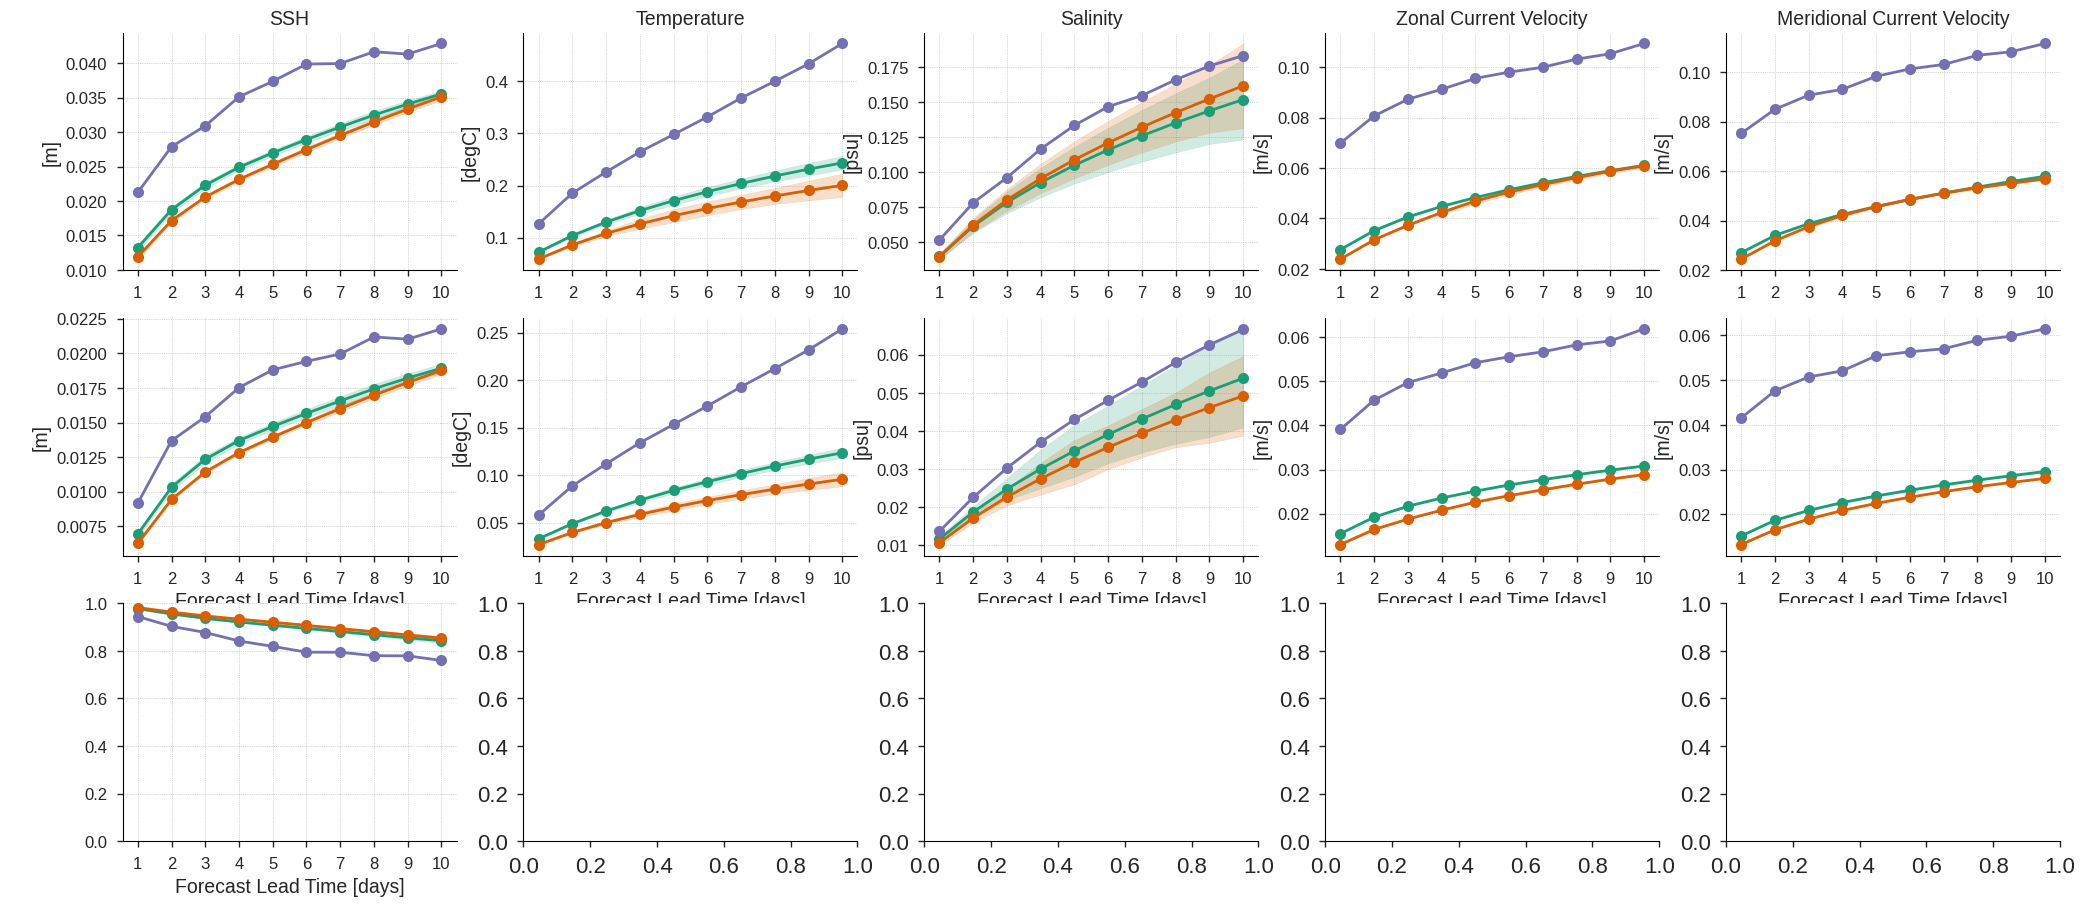

In [24]:
for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} ---")

    # Calculate grid dimensions
    ncols = len(var_list)  # Columns correspond to vars
    nrows = len(metrics)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * (ncols if ncols > 0 else 1), 3.5 * nrows))
    
    # Plot
    for i, metric in enumerate(metrics):
        print("metric:", metric)

        for j, var in enumerate(var_list):
            print("variable:", var)
            
            for config in MODELS_CONFIG:
                z_val = z_l if var!= "SSH" else None
                is_top_row = True if i==0 else False
                
                plot_model_data(
                    ax=axes[i][j], model_config=config, truth_key=truth, var_key=var,
                    metric=metric, z_val=z_val, depth_unit=depth_unit,
                    is_top_row=is_top_row, is_left_col=False, is_bottom_row= not is_top_row,
                )

    # --- Finalize Figure ---
    # Remove individual legends
    for ax in fig.axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # Shared Legend
    handles, labels = [], []
    for ax in fig.axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    
    fig.legend(
        handles, labels, 
        loc='lower center', ncol=len(MODELS_CONFIG), 
        bbox_to_anchor=(0.5, 0.01)
    )
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    
    if SAVE_PLOT:
        figname = f"Surface_variables_MSE_M-Loss_Persistence_10-day_lead_RMSE_MAE_ACC.png"
        if APPLY_LATITUDE_WEIGHTING:
            figname = f"LW-{figname}"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

In [45]:
type(all_sq_error)

dict